Imports + paths

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

“Assumptions” table cell (constants in ONE place)

In [2]:
# -----------------------------
# Model params (fill with your chosen model)
# -----------------------------
L = 32          # layers
H = 32          # heads
Dh = 128        # head dim
d = H * Dh      # model width

# -----------------------------
# Hardware params (from your Day 2 roofline)
# -----------------------------
PEAK_FLOPS = 312e12      # FLOPs/s
PEAK_BW = 1.6e12         # bytes/s

# -----------------------------
# Energy constants (model assumptions)
# -----------------------------
E_BYTE_HBM = 5e-12       # J/byte (HBM energy)
E_FLOP = 1e-12           # J/FLOP (optional)

T_vals = np.array([128, 256, 512, 1024, 2048])

# Precision (bytes/element)
FP16 = 2
INT8 = 1

In [3]:
print("d =", d)
print("T_vals =", T_vals)

d = 4096
T_vals = [ 128  256  512 1024 2048]


We model incremental decoding at step t = T

In [4]:
def bytes_attention_per_token(T, kv_bytes):
    # KV read: read all past KV for all layers
    kv_read = 2 * L * H * Dh * T * kv_bytes

    # KV write: write KV for current token
    kv_write = 2 * L * H * Dh * kv_bytes

    return kv_read + kv_write

In [5]:
for T in [128, 2048]:
    print(T, bytes_attention_per_token(T, FP16))

128 67633152
2048 1074266112


FFN traffic cell (parameterized)

In [6]:
def bytes_ffn_per_token(weight_bytes=2, alpha=8):
    # Very conservative: assume weights are streamed each token
    # alpha ~ 8 captures ~8*d^2 weight reads per layer (2-layer MLP ballpark)
    weight_read = L * alpha * (d * d) * weight_bytes
    return weight_read

In [7]:
T = 2048
print("Attn bytes:", bytes_attention_per_token(T, FP16))
print("FFN  bytes:", bytes_ffn_per_token(weight_bytes=FP16, alpha=8))

Attn bytes: 1074266112
FFN  bytes: 8589934592


4.1 Attention FLOPs (decode) cell

In [8]:
def flops_attention_per_token(T):
    # QK^T (dot products) + weighted sum; simplified scaling
    # proportional to L * H * T * Dh
    return 4 * L * H * T * Dh

4.2 FFN FLOPs cell

In [9]:
def flops_ffn_per_token(alpha=8):
    # Keep consistent with weight traffic alpha; ballpark is O(L*d^2)
    return alpha * L * d * d

4.3 Total FLOPs

In [10]:
def flops_total_per_token(T, alpha_ffn=8):
    return flops_attention_per_token(T) + flops_ffn_per_token(alpha=alpha_ffn)

5) Energy/token functions (memory-only + optional compute)

In [12]:
def energy_per_token(T, kv_bytes, E_byte=E_BYTE_HBM, include_compute=False, alpha_ffn=8):
    attn_bytes = bytes_attention_per_token(T, kv_bytes)
    ffn_bytes = bytes_ffn_per_token(weight_bytes=FP16, alpha=alpha_ffn)  # assume FFN weights are FP16

    total_bytes = attn_bytes + ffn_bytes
    E_mem = total_bytes * E_byte

    if not include_compute:
        return E_mem

    flops = flops_total_per_token(T, alpha_ffn=alpha_ffn)
    E_comp = flops * E_FLOP
    return E_mem + E_comp

print("Energy/token FP16 KV @2048:", energy_per_token(2048, FP16))
print("Energy/token INT8 KV @2048:", energy_per_token(2048, INT8))

Energy/token FP16 KV @2048: 0.048321003519999996
Energy/token INT8 KV @2048: 0.04563533824


6) Latency/token (roofline max(mem, compute))

In [13]:
def latency_per_token(T, kv_bytes, alpha_ffn=8):
    attn_bytes = bytes_attention_per_token(T, kv_bytes)
    ffn_bytes = bytes_ffn_per_token(weight_bytes=FP16, alpha=alpha_ffn)
    total_bytes = attn_bytes + ffn_bytes

    flops = flops_total_per_token(T, alpha_ffn=alpha_ffn)

    t_mem = total_bytes / PEAK_BW
    t_comp = flops / PEAK_FLOPS

    return max(t_mem, t_comp), t_mem, t_comp

for T in T_vals:
    t, tm, tc = latency_per_token(T, FP16)
    print(f"T={T}  total={t:.3e}  mem={tm:.3e}  comp={tc:.3e}  dominated_by={'mem' if tm>tc else 'comp'}")

T=128  total=5.411e-03  mem=5.411e-03  comp=1.398e-05  dominated_by=mem
T=256  total=5.453e-03  mem=5.453e-03  comp=1.420e-05  dominated_by=mem
T=512  total=5.537e-03  mem=5.537e-03  comp=1.463e-05  dominated_by=mem
T=1024  total=5.705e-03  mem=5.705e-03  comp=1.549e-05  dominated_by=mem
T=2048  total=6.040e-03  mem=6.040e-03  comp=1.721e-05  dominated_by=mem


7) Plot 1 — Energy/token vs T (FP16 vs INT8 KV)

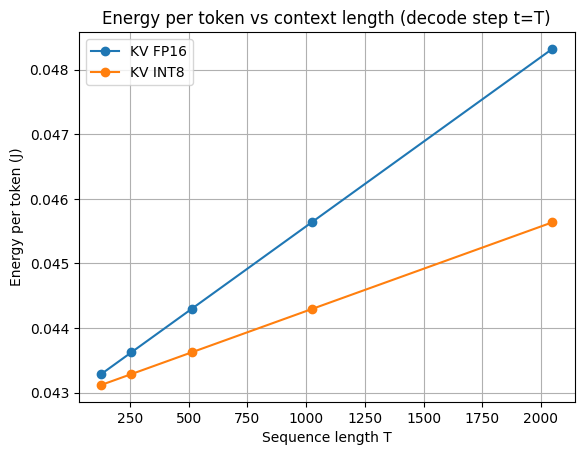

In [16]:
E_fp16 = np.array([energy_per_token(T, FP16) for T in T_vals])
E_int8 = np.array([energy_per_token(T, INT8) for T in T_vals])

plt.figure()
plt.plot(T_vals, E_fp16, marker="o")
plt.plot(T_vals, E_int8, marker="o")
plt.xlabel("Sequence length T")
plt.ylabel("Energy per token (J)")
plt.title("Energy per token vs context length (decode step t=T)")
plt.legend(["KV FP16", "KV INT8"])
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "energy_vs_seq.png"), dpi=200, bbox_inches="tight")
plt.show()

8) Plot 2 — Latency/token vs T (FP16 vs INT8 KV)

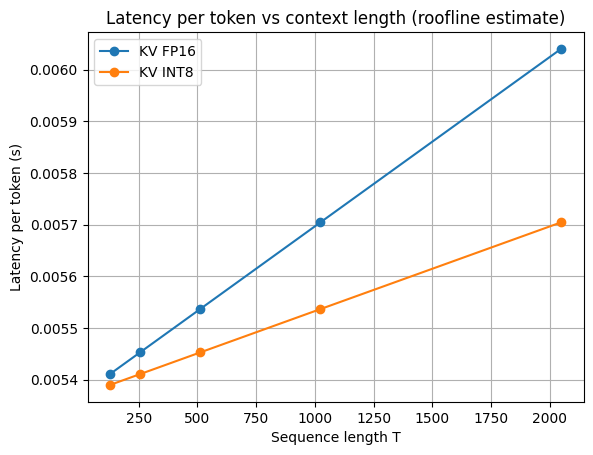

In [15]:
L_fp16 = np.array([latency_per_token(T, FP16)[0] for T in T_vals])
L_int8 = np.array([latency_per_token(T, INT8)[0] for T in T_vals])

plt.figure()
plt.plot(T_vals, L_fp16, marker="o")
plt.plot(T_vals, L_int8, marker="o")
plt.xlabel("Sequence length T")
plt.ylabel("Latency per token (s)")
plt.title("Latency per token vs context length (roofline estimate)")
plt.legend(["KV FP16", "KV INT8"])
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "latency_vs_seq.png"), dpi=200, bbox_inches="tight")
plt.show()

9) Plot 3 — Breakdown plot (attention bytes vs FFN bytes)

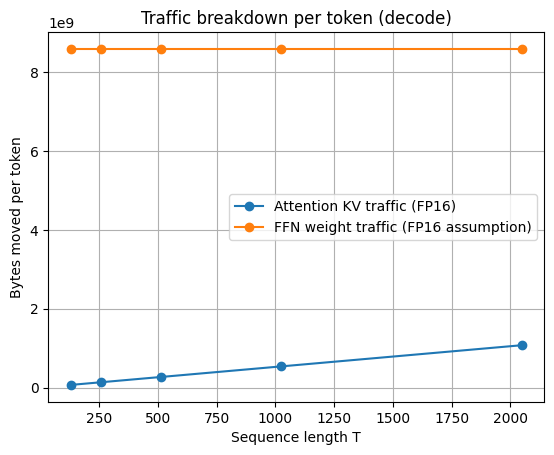

In [17]:
attn_bytes_fp16 = np.array([bytes_attention_per_token(T, FP16) for T in T_vals])
ffn_bytes = np.array([bytes_ffn_per_token(weight_bytes=FP16, alpha=8) for _ in T_vals])

plt.figure()
plt.plot(T_vals, attn_bytes_fp16, marker="o")
plt.plot(T_vals, ffn_bytes, marker="o")
plt.xlabel("Sequence length T")
plt.ylabel("Bytes moved per token")
plt.title("Traffic breakdown per token (decode)")
plt.legend(["Attention KV traffic (FP16)", "FFN weight traffic (FP16 assumption)"])
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "bytes_breakdown.png"), dpi=200, bbox_inches="tight")
plt.show()